# PUMP — region, sample and pump comparison

**Diagnostic notebook only:** inspect repeatability; no feature selection, model fitting, prediction, or changes to existing feature CSVs.

Choose one fault, state, region, signal/channel, and any pumps/samples in cell 2. Change the selection and rerun from cell 3 onward. To change only the pump shown in the within-pump plot, call its plotting function again with another pump number.

The notebook shows:
1. Full recordings with all changepoints/region labels, beside an enlarged selected region with division boundaries and six annotated feature values.
2. Division-to-division feature trends for every sample of one pump.
3. Sample-to-sample comparisons of the **same division** within that pump.
4. Comparisons between pumps for each corresponding division, showing individual samples, pump means and sample SD.
5. Six sample/division heatmaps and numerical within-pump/between-pump variation tables.

Region numbers start at **0**. Division numbers start at **1**. Three divisions means three consecutive equal-row windows over the selected region (after optional edge trimming); all usable rows are included once. This is a diagnostic division of the region, not the fixed central window used by the training feature notebook. Equal fractions of a region are comparable only when the changepoints identify the same operating sequence.

Six features: **RMS, standard deviation, MAD, q95, skewness and excess kurtosis**. The default reproduces the PUMP statistics notebook's 2.5–97% quantile trimming and AC1/GYR median-centring rules; q95 and MAD retain the original definition. Set `TRIM_QUANTILES=None` for untrimmed diagnostic features. Raw plots always show untrimmed values. Units remain the CSV's units; no calibration is inferred.

Requirements: `numpy pandas polars scipy matplotlib tqdm`. Input: the combined PUMP metadata/timestamp CSVs **and the raw signal CSVs referenced by them**. Previously extracted feature tables cannot reconstruct within-region divisions.

In [92]:
import os
os.environ.setdefault("POLARS_MAX_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from tqdm.auto import tqdm
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if isinstance(value, pd.DataFrame) else value)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.18})
pd.set_option("display.max_columns", 30)

## 1. Choose the comparison

`PUMP_IDS=None` / `SAMPLE_IDS=None` includes all available IDs for the selected fault/state. IDs may be integers or strings. `FOCUS_PUMP=None` selects the first available pump for the within-pump plots; all selected pumps still enter the between-pump plots. Set `REGION_EDGE_SECONDS=0` to include the entire changepoint interval, including transitions.

In [93]:
META_PATH = Path("pump_meta_combined_all_faults_mapped.csv")
TIMESTAMPS_PATH = Path("pump_signalwise_timestamp_combined.csv")
PATH_REPLACEMENTS = {}  # e.g. {r"D:\VGuard Ahemedebad Data": r"E:\PumpData"}

FAULT_ID = "00000000000_"
STATE = "water"          # "air" or "water"
REGION = 0               # Air: 0–1; Water: 0–3 for the supplied dataset
SIGNAL = "AC1"           # CV1, VRY, CTB, CTR, SMG, AC1, GYR, PRS or WTF
COLUMN = "2"             # AC1/GYR: 0/1/2; VRY: 0/1; others: 0
PUMP_IDS = None         # e.g. [1, 2, 3]
SAMPLE_IDS = None        # e.g. [1, 2, 3, 4, 5]
FOCUS_PUMP = None        # e.g. 1
N_DIVISIONS = 3
REGION_EDGE_SECONDS = 0.25
TRIM_QUANTILES = (0.025, 0.97)  # None = no outlier trimming
MIN_DIVISION_SAMPLES = 32

# Bound only plot previews; features use every original row in each division.
MAX_TRACE_POINTS = 10000
SAMPLES_PER_FIGURE = 3
SAVE_PLOTS = False
EXPORT_TABLES = False
OUTPUT_ROOT = Path("pump_comparison_outputs")

# Future merged-file equivalents: only established non-electrical names are
# prefilled. Explicitly configure electrical channels before comparing them.
NEW_RAW_COLUMNS = {
    "AC1": {"0": "ac1", "1": "ac2", "2": "ac3"},
    "GYR": {"0": "gy1", "1": "gy2", "2": "gy3"},
    "SMG": {"0": "mag"}, "PRS": {"0": "prs"}, "WTF": {"0": "wtf"},
    "CV1": {}, "VRY": {}, "CTB": {}, "CTR": {},
}

## 2. Inspect available faults and selected samples

No healthy/single-fault filter is applied: any fault in the metadata can be inspected. Air/Water pairing is not required for this single-state diagnostic.

In [94]:
FEATURES = ["rms", "std", "mad", "q95", "skew", "kurt"]
LABELS = {"rms": "RMS", "std": "Standard deviation", "mad": "MAD",
          "q95": "95th percentile", "skew": "Skewness", "kurt": "Excess kurtosis"}

def normalize_id(value):
    number = float(value)
    if not np.isfinite(number) or number < 0 or number != int(number):
        raise ValueError(f"Expected a nonnegative integer pump/sample ID, got {value}")
    return str(int(number))

meta = pd.read_csv(META_PATH, dtype={"fault_id": str, "pump_id": str, "sample_id": str})
orig_ts = pd.read_csv(TIMESTAMPS_PATH, dtype=str)
meta["fault_id"] = meta["fault_id"].str.strip()
meta["state"] = meta["state"].str.strip().str.lower()
for col in ["pump_id", "sample_id"]:
    meta[col] = meta[col].map(normalize_id)
meta["sample_id_key"] = meta[["fault_id", "pump_id", "sample_id"]].agg("@".join, axis=1)
meta["state_id_key"] = meta["sample_id_key"] + "@" + meta["state"]
if meta["state_id_key"].duplicated().any() or orig_ts["id"].duplicated().any():
    raise ValueError("Duplicate sample/state or signalwise timestamp IDs")
orig_ts_lookup = dict(zip(orig_ts["id"], orig_ts["indices"]))
fault_inventory = meta.groupby(["fault_id", "state"]).agg(
    pumps=("pump_id", "nunique"), samples=("sample_id_key", "nunique")
).reset_index()
display(fault_inventory)

FAULT_ID, STATE, SIGNAL, COLUMN = str(FAULT_ID).strip(), STATE.strip().lower(), SIGNAL.upper(), str(COLUMN)
if STATE not in ["air", "water"]:
    raise ValueError("STATE must be air or water")
if not isinstance(N_DIVISIONS, int) or N_DIVISIONS < 1:
    raise ValueError("N_DIVISIONS must be a positive integer")
if not isinstance(REGION, int) or REGION < 0 or REGION_EDGE_SECONDS < 0:
    raise ValueError("REGION and REGION_EDGE_SECONDS must be nonnegative")
if MAX_TRACE_POINTS < 4 or SAMPLES_PER_FIGURE < 1 or MIN_DIVISION_SAMPLES < 4:
    raise ValueError("Invalid plot/division size settings")
if TRIM_QUANTILES is not None and not (0 <= TRIM_QUANTILES[0] < TRIM_QUANTILES[1] <= 1):
    raise ValueError("Invalid quantile bounds")
selected = meta[(meta["fault_id"] == FAULT_ID) & (meta["state"] == STATE)].copy()
for setting, col in [(PUMP_IDS, "pump_id"), (SAMPLE_IDS, "sample_id")]:
    if setting is not None:
        requested = {normalize_id(v) for v in setting}
        missing = requested - set(selected[col])
        if missing:
            raise ValueError(f"Requested {col} values not found: {sorted(missing)}")
        selected = selected[selected[col].isin(requested)]
if selected.empty:
    raise ValueError("No samples match this selection. Check the inventory above.")
if SIGNAL not in selected or selected[SIGNAL].isna().any():
    raise ValueError(f"{SIGNAL} is unavailable for one or more {STATE} samples; PRS/WTF are Water-only.")
selected = selected.sort_values(["pump_id", "sample_id"], key=lambda c: c.astype(int)).reset_index(drop=True)
focus_pump = normalize_id(FOCUS_PUMP) if FOCUS_PUMP is not None else selected.iloc[0]["pump_id"]
if focus_pump not in set(selected["pump_id"]):
    raise ValueError("FOCUS_PUMP is not in the selected pump list")
for row in selected.itertuples():
    key = f"{SIGNAL}_{row.state_id_key}"
    if key not in orig_ts_lookup:
        raise ValueError(f"Missing changepoints: {key}")
    cp = np.array(orig_ts_lookup[key].split("#"), dtype=np.int64)
    if len(cp) < 2 or cp[0] < 0 or np.any(np.diff(cp) <= 0) or REGION >= len(cp)-1:
        raise ValueError(f"Invalid boundaries/region for {key}: {cp}")

selection_title = f"{FAULT_ID} | {STATE} | region {REGION} | {SIGNAL} column {COLUMN}"
output_dir = OUTPUT_ROOT / f"{FAULT_ID}_{STATE}_r{REGION}_{SIGNAL}_col{COLUMN}_d{N_DIVISIONS}"
print(selection_title)
print(f"{len(selected)} samples from {selected.pump_id.nunique()} pumps; focus pump: {focus_pump}")
display(selected[["fault_id", "pump_id", "sample_id", "state", "sample_id_key"]])

,fault_id,state,pumps,samples
0,00000000000_,air,3,10
1,00000000000_,water,3,10
2,00000000001_,air,3,15
3,00000000001_,water,3,15
4,00000000010_,air,3,15
...,...,...,...,...
71,40000001000_,water,3,15
72,40000100000_,air,3,14
73,40000100000_,water,3,14
74,40100000000_,air,3,15


00000000000_ | water | region 0 | AC1 column 2
10 samples from 3 pumps; focus pump: 1


,fault_id,pump_id,sample_id,state,sample_id_key
0,00000000000_,1,1,water,00000000000_@1@1
1,00000000000_,1,4,water,00000000000_@1@4
2,00000000000_,2,1,water,00000000000_@2@1
3,00000000000_,2,2,water,00000000000_@2@2
4,00000000000_,2,3,water,00000000000_@2@3
5,00000000000_,2,4,water,00000000000_@2@4
6,00000000000_,2,5,water,00000000000_@2@5
7,00000000000_,3,3,water,00000000000_@3@3
8,00000000000_,3,4,water,00000000000_@3@4
9,00000000000_,3,5,water,00000000000_@3@5


## 3. Loading, division and feature functions

Raw row positions are preserved: no row is removed before applying changepoints. The displayed elapsed-time axis uses row number / estimated sample rate, as a uniform-time approximation; division indices are exact. Only one raw channel is loaded at a time. Min/max plot previews preserve the amplitude envelope, but cannot show every oscillation; they are never used to calculate features.

In [95]:
def resolve_path(value):
    path = str(value)
    for old, new in PATH_REPLACEMENTS.items():
        if path.startswith(old):
            path = str(new) + path[len(old):]
            break
    return path.replace("\\", "/") if os.name != "nt" else path

def load_signal(row):
    path = resolve_path(row[SIGNAL])
    header = pd.read_csv(path, nrows=0).columns.tolist()
    new_time = next((c for c in ["firmware_timestamp", "F_Timestamp"] if c in header), None)
    timecol = new_time or "Timestamp"
    candidates = [f"{SIGNAL}_column_{COLUMN}"]
    if new_time:
        mapped = NEW_RAW_COLUMNS.get(SIGNAL, {}).get(COLUMN)
        if mapped:
            candidates.append(mapped)
    else:
        candidates += [f"column_{COLUMN}", COLUMN]
    col = next((c for c in candidates if c in header), None)
    if col is None or timecol not in header:
        raise ValueError(f"Missing/unmapped timestamp or {SIGNAL}/{COLUMN} in {path}")
    df = pl.read_csv(path, columns=[timecol, col], n_threads=1, low_memory=True, rechunk=False)
    times = df[timecol].to_numpy().astype(float)
    if new_time:
        times /= 1e6
    valid = np.flatnonzero(np.isfinite(times) & (times >= 0))
    if len(valid) < 2 or times[valid[-1]] <= times[valid[0]]:
        raise ValueError(f"Invalid timestamp duration: {path}")
    fs = (valid[-1] - valid[0]) / (times[valid[-1]] - times[valid[0]])
    values = df[col].to_numpy().astype(float)
    key = f"{SIGNAL}_{row['state_id_key']}"
    cp = np.array(orig_ts_lookup[key].split("#"), dtype=np.int64)
    if cp[-1] > len(values):
        raise ValueError(f"Changepoints exceed raw row count: {key}")
    return values, float(fs), cp

def division_bounds(cp, fs):
    edge = int(np.ceil(REGION_EDGE_SECONDS * fs))
    ll, ul = int(cp[REGION]) + edge, int(cp[REGION + 1]) - edge
    if ul - ll < N_DIVISIONS * MIN_DIVISION_SAMPLES:
        raise ValueError(f"Region {REGION} too short for {N_DIVISIONS} divisions after edge trimming")
    # Integer boundaries partition every usable row once, with no overlap.
    bounds = np.linspace(ll, ul, N_DIVISIONS + 1, dtype=np.int64)
    return bounds

def common_features(values):
    x = np.asarray(values, dtype=float)
    if len(x) < MIN_DIVISION_SAMPLES or not np.isfinite(x).all():
        raise ValueError("Feature division is too short or contains NaN/Inf")
    if TRIM_QUANTILES is not None:
        series = pl.Series(x)
        low, high = [series.quantile(q) for q in TRIM_QUANTILES]
        x = series.filter(series.is_between(low, high)).to_numpy()
    if len(x) < 4:
        raise ValueError("Too few samples after quantile trimming")
    median = np.median(x)
    x_feat = x - median if SIGNAL in ["AC1", "GYR"] else x
    near_constant = np.ptp(x_feat) <= 1e-12 * max(1.0, float(np.max(np.abs(x_feat))))
    skewness = 0.0 if near_constant else float(skew(x_feat, bias=False))
    kurt = 0.0 if near_constant else float(kurtosis(x_feat, fisher=True, bias=False))
    return {"rms": float(np.sqrt(np.mean(x_feat**2))), "std": float(np.std(x_feat)),
            "mad": float(np.median(np.abs(x-median))), "q95": float(np.quantile(x,0.95)),
            "skew": skewness if np.isfinite(skewness) else 0.0,
            "kurt": kurt if np.isfinite(kurt) else 0.0, "retained_samples": len(x)}

def envelope_preview(values, fs, offset=0):
    x = np.asarray(values)
    if len(x) <= MAX_TRACE_POINTS:
        ids = np.arange(len(x))
    else:
        bounds = np.linspace(0, len(x), MAX_TRACE_POINTS//2 + 1, dtype=int)
        positions = []
        for lo, hi in zip(bounds[:-1], bounds[1:]):
            part = x[lo:hi]
            finite = np.flatnonzero(np.isfinite(part))
            if not len(finite):
                positions.append(lo)
                continue
            a = lo + finite[np.argmin(part[finite])]
            b = lo + finite[np.argmax(part[finite])]
            positions.extend(sorted({a, b}))
        ids = np.array(positions, dtype=int)
    return (ids + offset)/fs, x[ids]

def finish_plot(fig, name):
    fig.tight_layout(rect=(0,0,1,0.95))
    if SAVE_PLOTS:
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 4. Calculate diagnostic features for the selected region

This cell reads all selected raw files once. Later plotting cells reuse small previews and feature tables. Changing the fault, state, signal, region, or number of divisions requires rerunning from the inventory cell above.

In [96]:
records, previews = [], {}
for _, row in tqdm(selected.iterrows(), total=len(selected), desc="Comparing PUMP samples"):
    try:
        values, fs, cp = load_signal(row)
        bounds = division_bounds(cp, fs)
        for division, (lo, hi) in enumerate(zip(bounds[:-1], bounds[1:]), start=1):
            record = {"fault_id": FAULT_ID, "pump_id": row.pump_id, "sample_id": row.sample_id,
                      "sample_id_key": row.sample_id_key, "state": STATE, "signal": SIGNAL,
                      "column": COLUMN, "region": REGION, "division": division,
                      "start_row": int(lo), "end_row_exclusive": int(hi),
                      "start_s": lo/fs, "end_s": hi/fs, "duration_s": (hi-lo)/fs,
                      "raw_samples": int(hi-lo), "sampling_rate_hz": fs}
            record.update(common_features(values[lo:hi]))
            records.append(record)
        region_start, region_end = map(int, cp[REGION:REGION+2])
        previews[(row.pump_id, row.sample_id)] = {
            "full": envelope_preview(values, fs),
            "region": envelope_preview(values[region_start:region_end], fs, region_start),
            "cp_s": cp/fs, "division_s": bounds/fs,
        }
        del values
        gc.collect()
    except (ValueError, OSError, KeyError) as error:
        raise RuntimeError(f"{row.state_id_key}/{SIGNAL}/{COLUMN}: {error}") from error
feature_table = pd.DataFrame(records)
assert len(feature_table) == len(selected) * N_DIVISIONS
if not np.isfinite(feature_table[FEATURES].to_numpy()).all():
    raise ValueError("Non-finite comparison feature values")
print(f"Computed {len(feature_table)} division windows; no raw data were downsampled for features.")
display(feature_table[["pump_id", "sample_id", "division", "duration_s", "raw_samples"] + FEATURES])

Comparing PUMP samples: 100%|██████████| 10/10 [00:02<00:00,  3.93it/s]

Computed 30 division windows; no raw data were downsampled for features.


,pump_id,sample_id,division,duration_s,raw_samples,rms,std,mad,q95,skew,kurt
0,1,1,1,4.426006,86218,180.799706,180.731509,148.0,1283.0,-0.051873,-1.022715
1,1,1,2,4.426057,86219,171.119085,171.085042,140.0,1271.0,-0.045376,-1.017637
2,1,1,3,4.426057,86219,175.241262,175.233158,145.0,1276.0,-0.049380,-1.035835
3,1,4,1,6.529046,127409,82.760075,82.752991,61.0,1150.0,0.047987,-0.723362
4,1,4,2,6.529046,127409,84.152566,84.151550,64.0,1149.0,-0.009460,-0.820108
5,1,4,3,6.529097,127410,92.987630,92.979821,71.0,1165.0,0.034230,-0.842629
6,2,1,1,4.892711,95495,207.168661,207.102989,144.0,1341.0,-0.198683,-0.434219
7,2,1,2,4.892711,95495,206.330695,206.320260,138.0,1343.0,-0.186300,-0.359846
8,2,1,3,4.892711,95495,207.188271,207.182094,140.0,1346.0,-0.166724,-0.393172
9,2,2,1,4.944279,96474,239.567289,239.441702,175.0,1402.0,0.017854,-0.684280


## 5. Full signals and annotated region divisions

Each row is one sample. Left: full signal and all original changepoints. Right: selected region with dashed division boundaries and the six values for each division. Grey edge areas, when present, are excluded from feature calculations. Shared y-limits across selected recordings preserve amplitude comparisons.

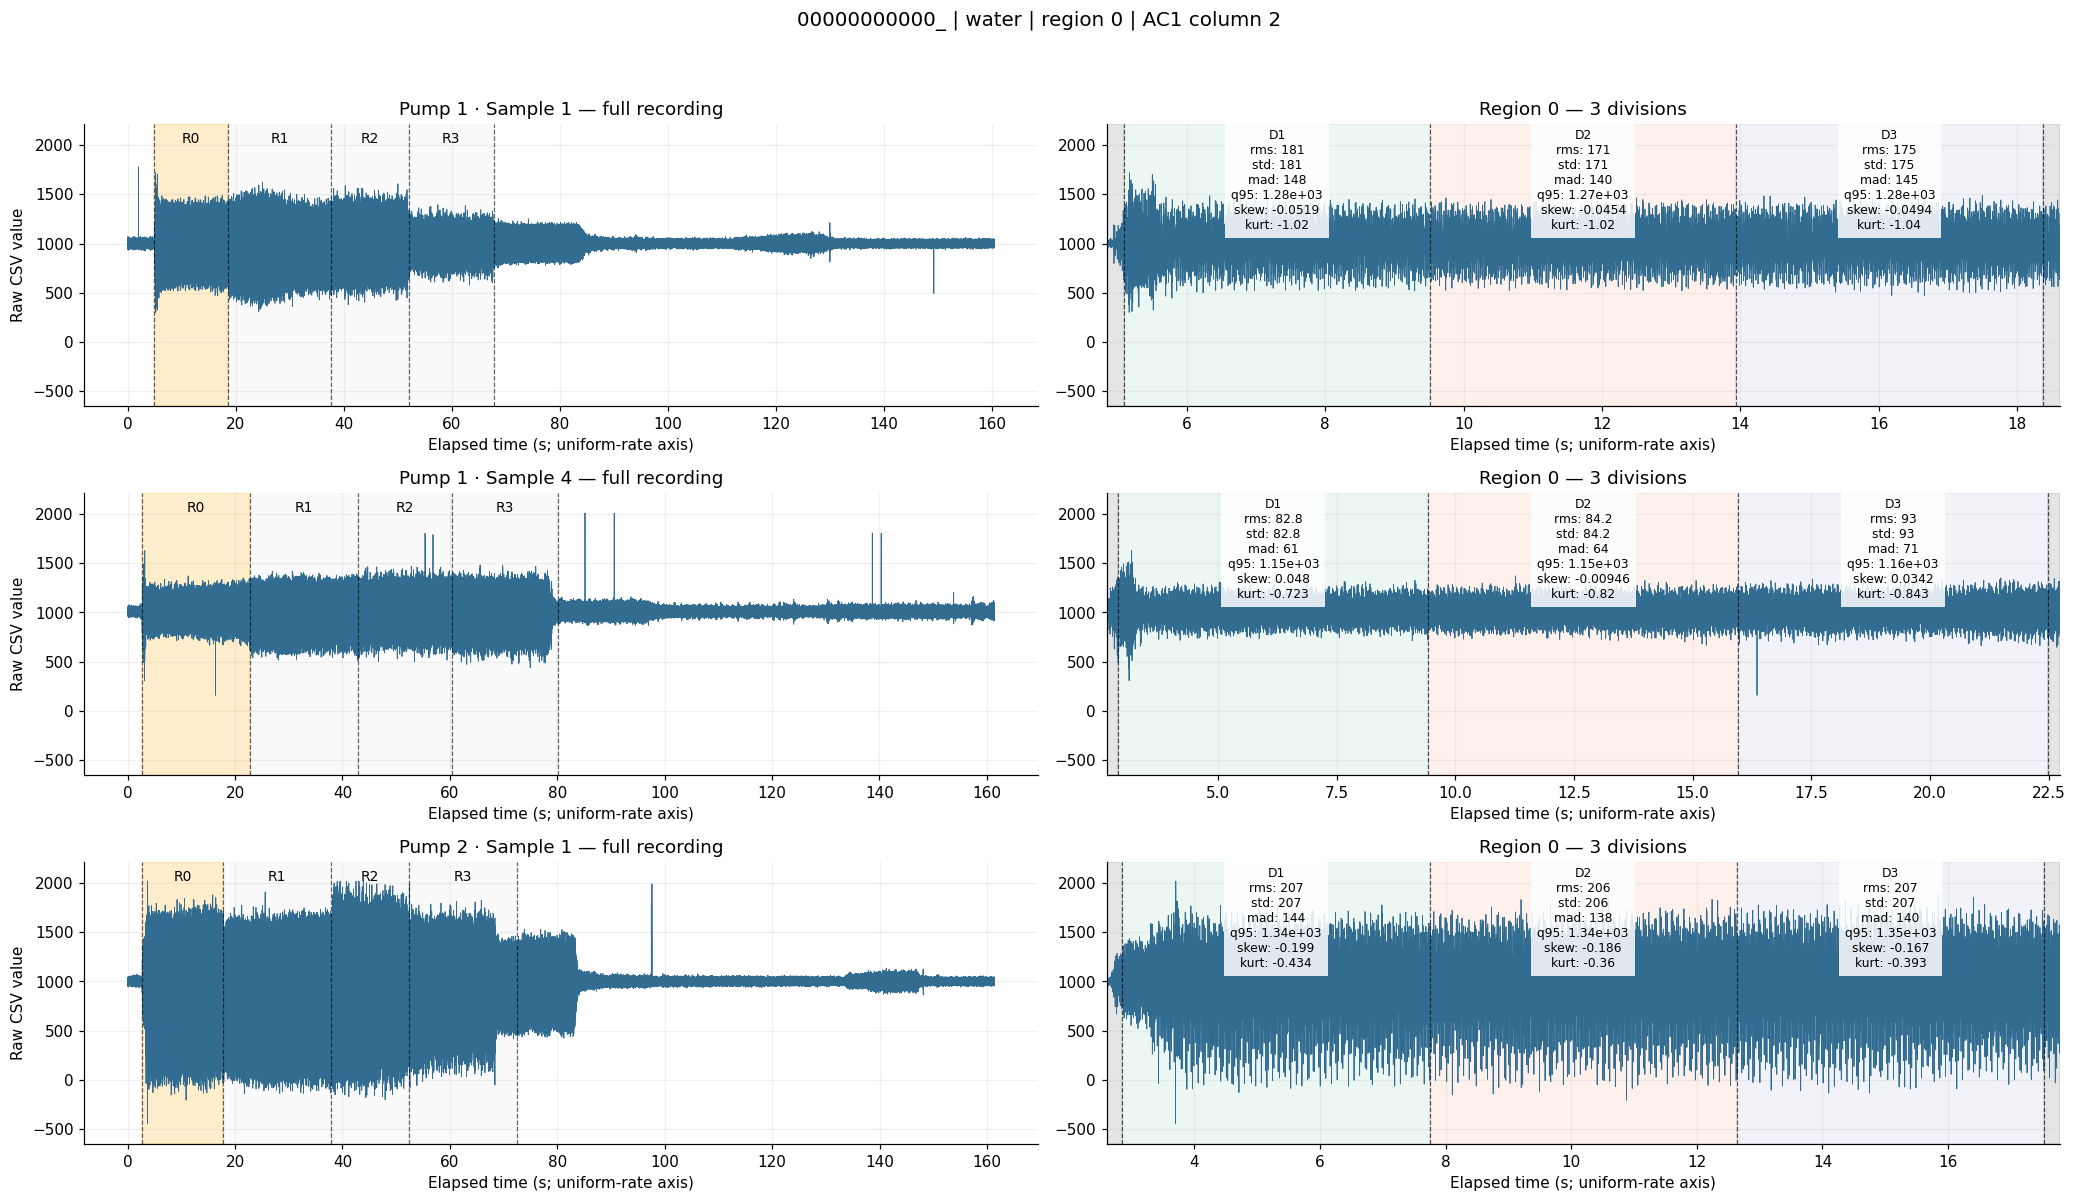

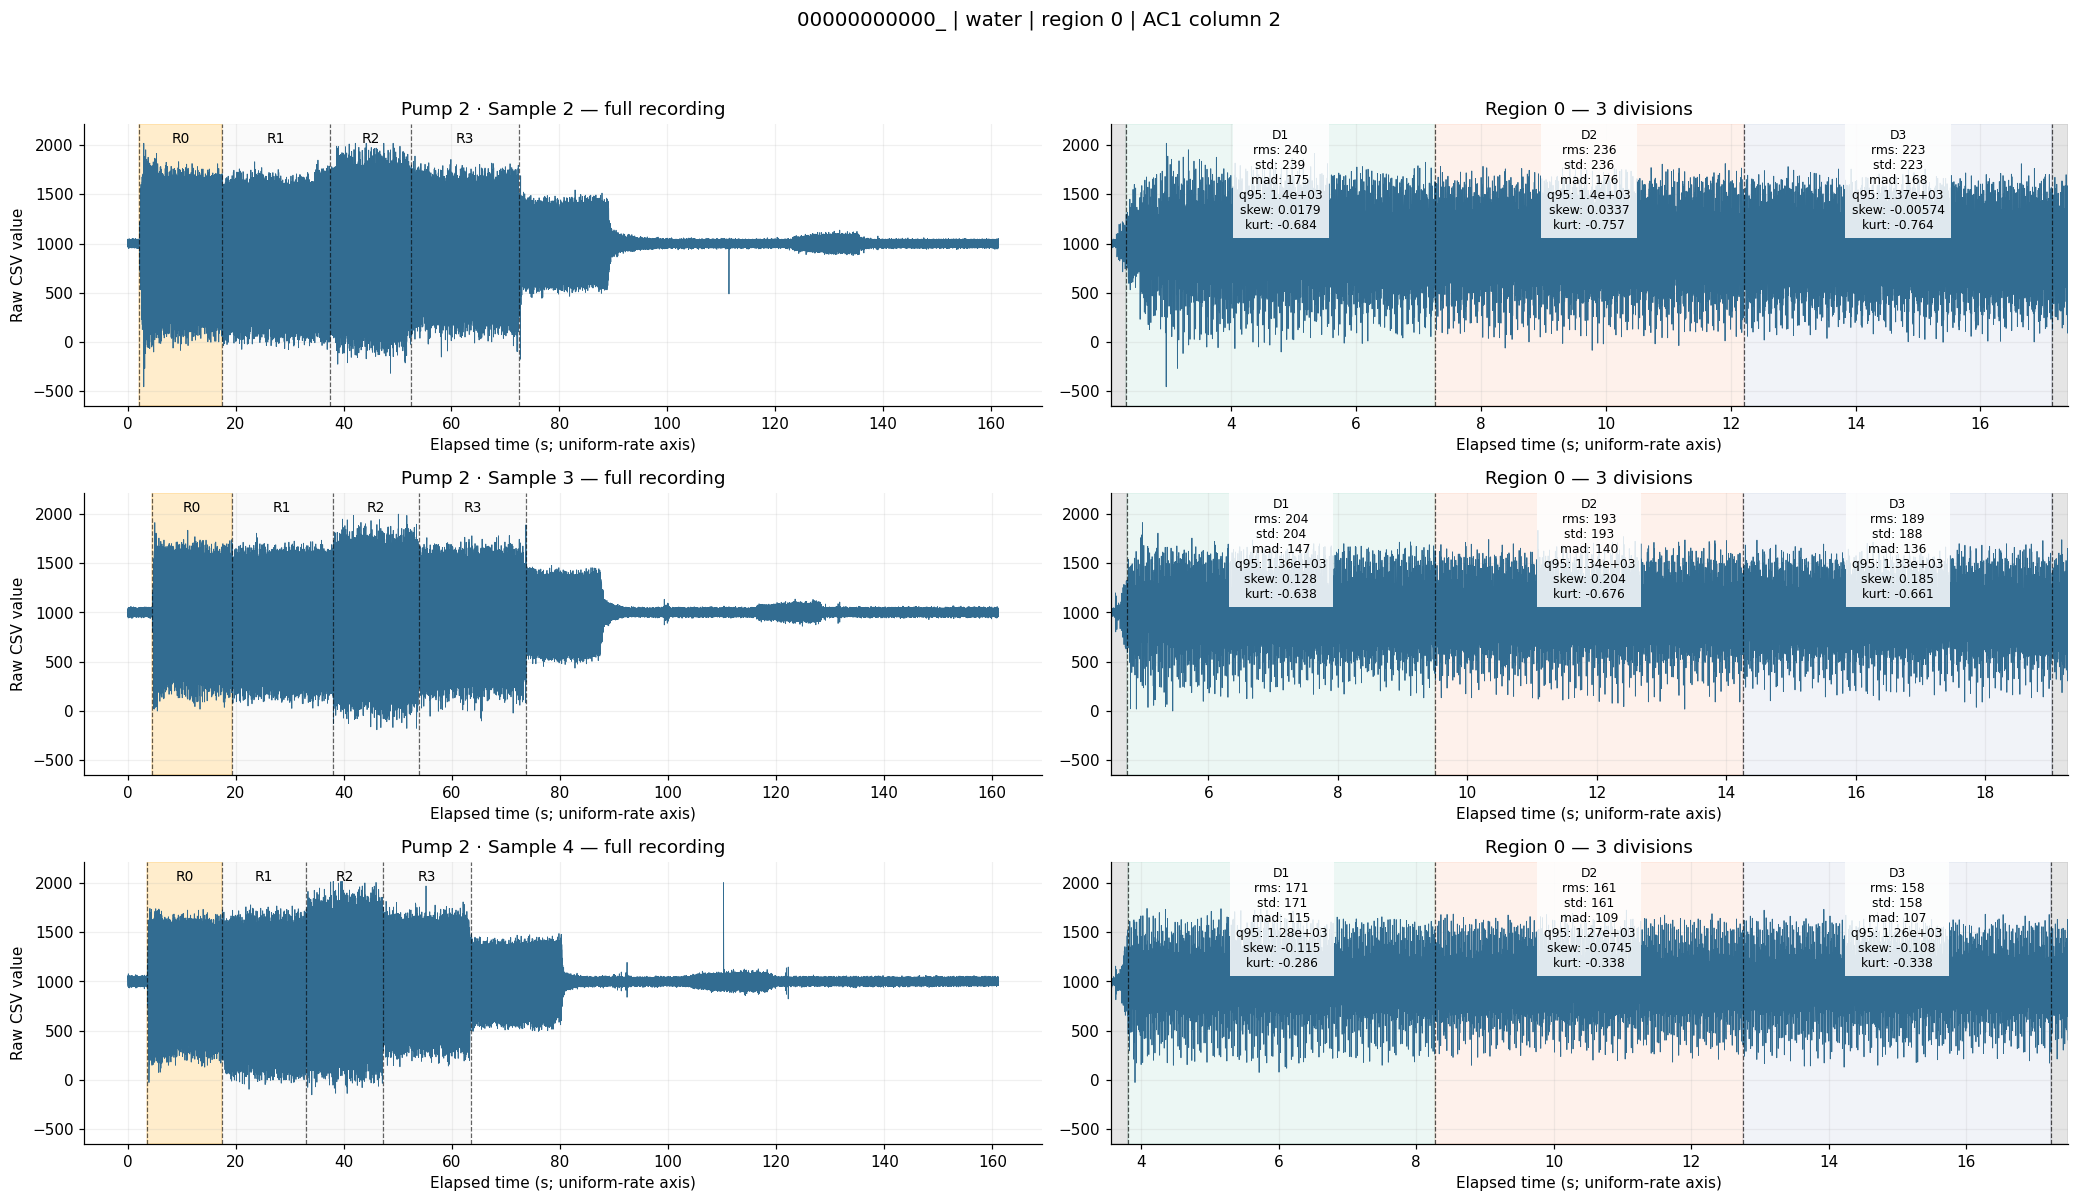

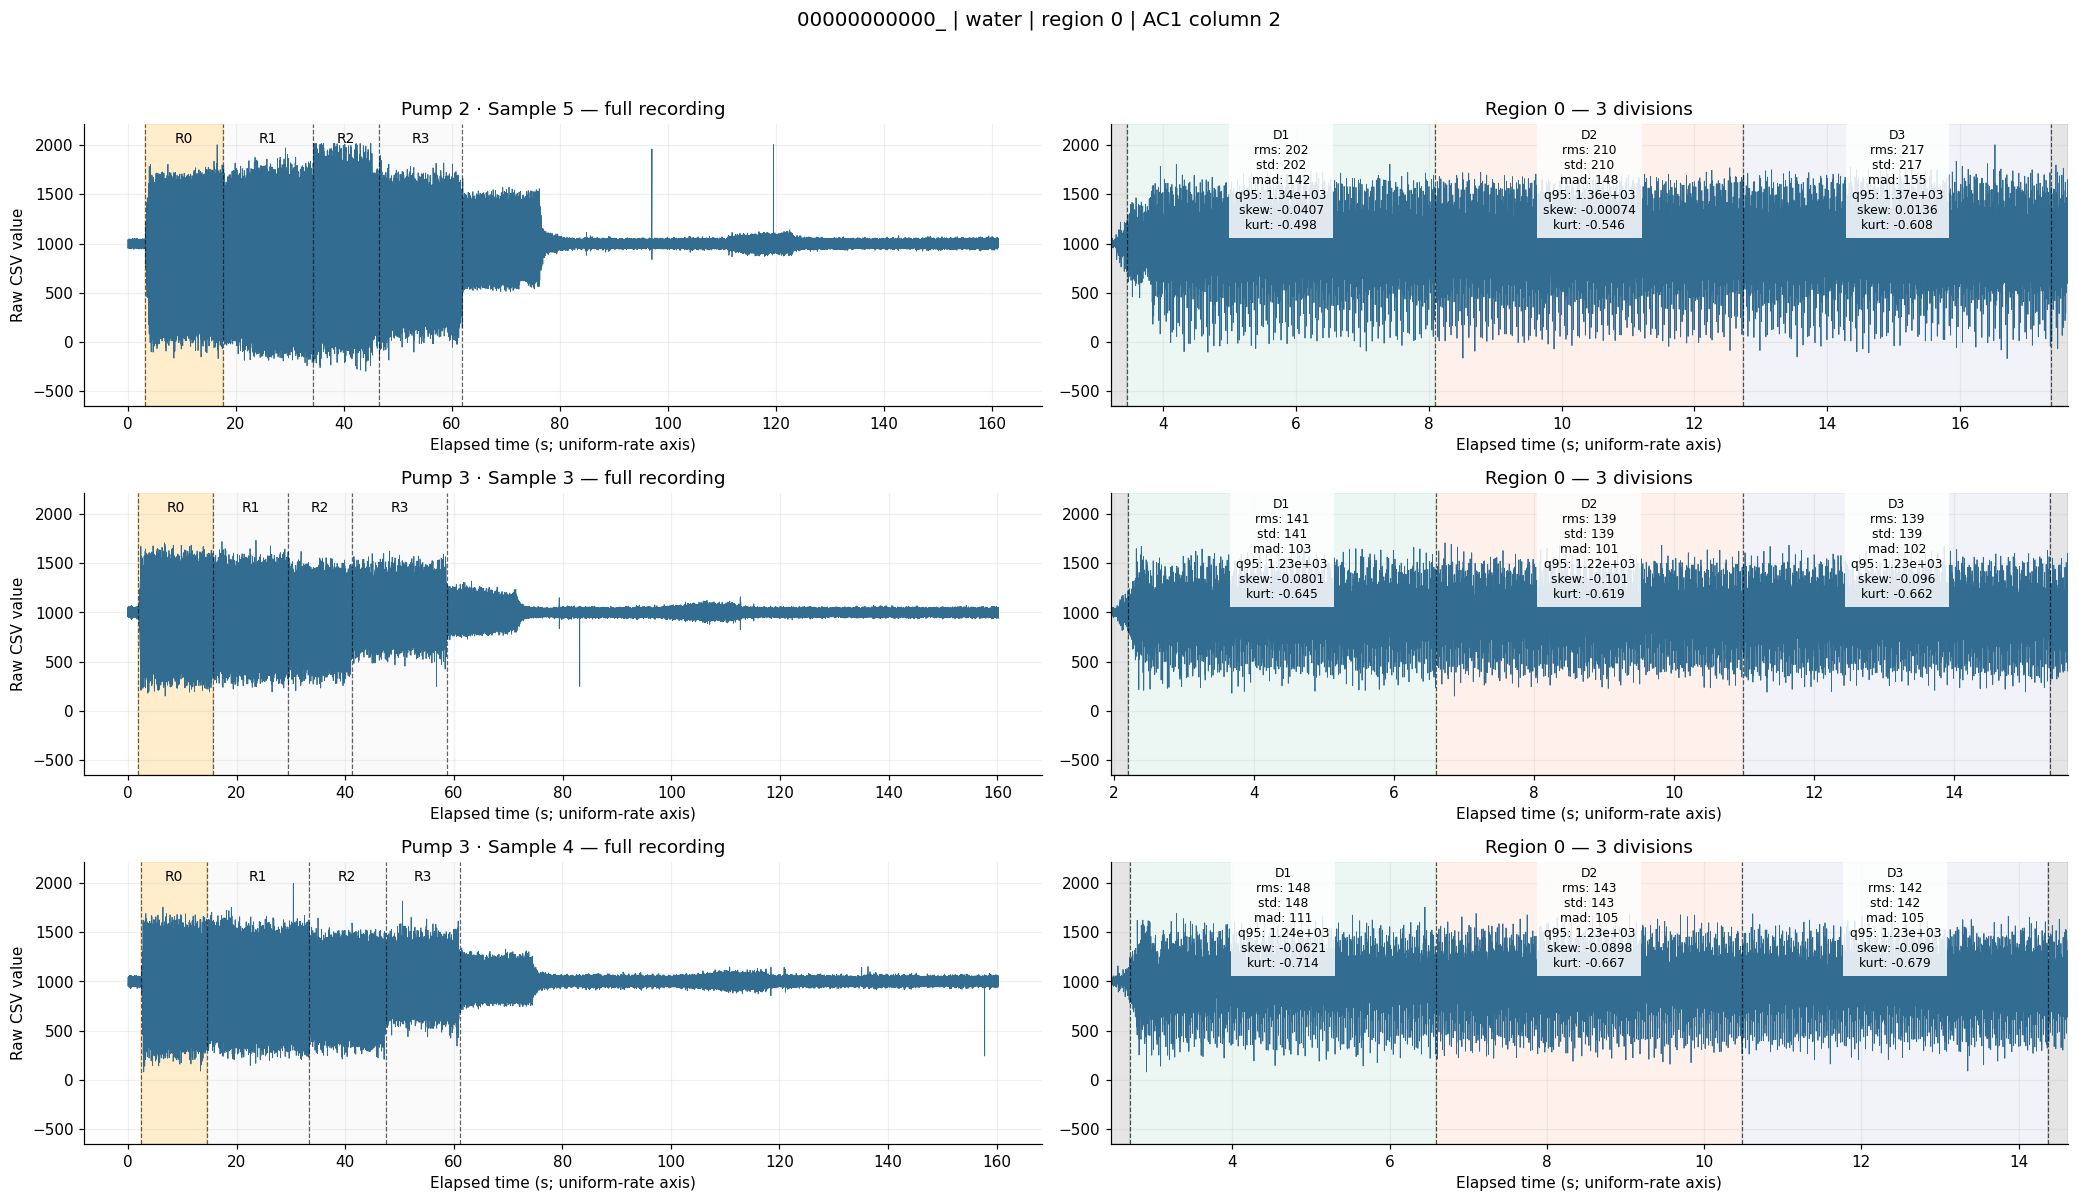

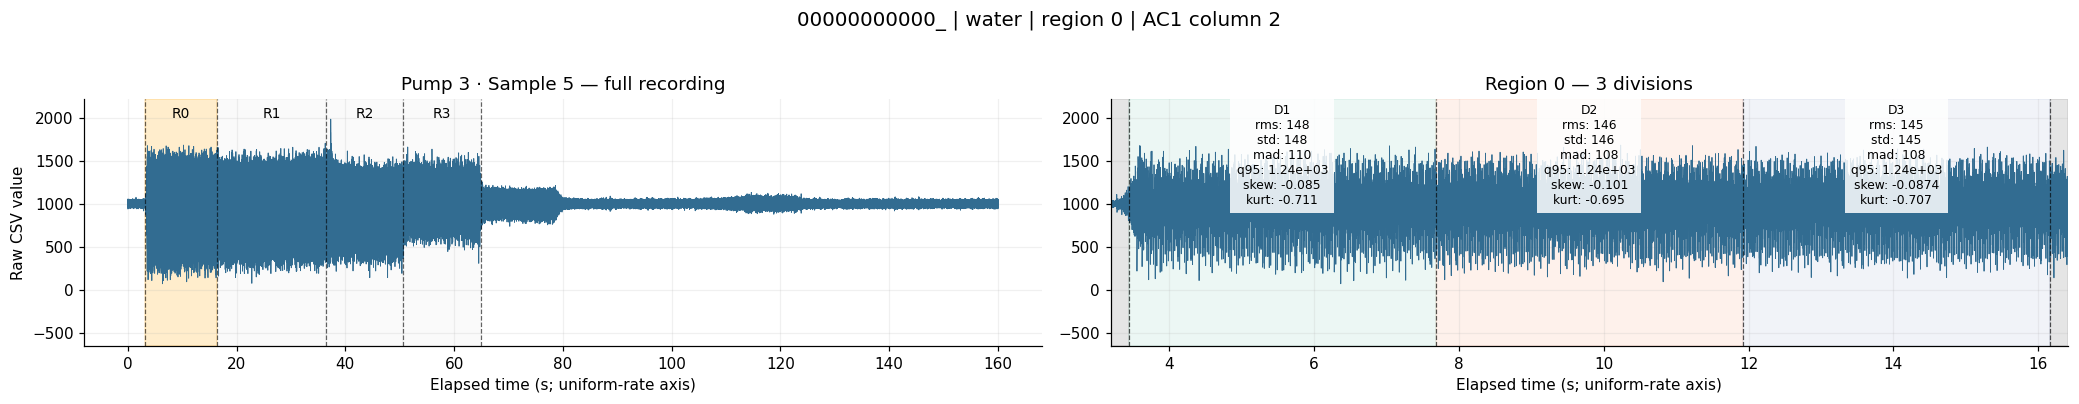

In [97]:
def plot_signal_regions(pump_id=None):
    items = [(key, view) for key, view in previews.items()
             if pump_id is None or key[0] == normalize_id(pump_id)]
    if not items:
        raise ValueError("No preview for this pump")
    finite_values = [v["full"][1][np.isfinite(v["full"][1])] for _, v in items]
    ymin = min(np.min(x) for x in finite_values if len(x))
    ymax = max(np.max(x) for x in finite_values if len(x))
    pad = max((ymax-ymin)*0.08, 1e-9)
    for page, start in enumerate(range(0, len(items), SAMPLES_PER_FIGURE), start=1):
        chunk = items[start:start + SAMPLES_PER_FIGURE]
        fig, axes = plt.subplots(len(chunk), 2, figsize=(19, 3.7*len(chunk)), squeeze=False)
        for (pump, sample), view, axrow in [(key, view, axrow) for (key, view), axrow in zip(chunk, axes)]:
            full, zoom = axrow
            full.plot(*view["full"], lw=0.55, color="#326c91")
            cp, bounds = view["cp_s"], view["division_s"]
            for j in range(len(cp)-1):
                full.axvspan(cp[j], cp[j+1], color="orange" if j==REGION else "grey",
                             alpha=0.20 if j==REGION else 0.04)
                full.text((cp[j]+cp[j+1])/2, 0.97, f"R{j}", ha="center", va="top",
                          transform=full.get_xaxis_transform(), fontsize=9)
            for x in cp:
                full.axvline(x, color="black", lw=0.8, ls="--", alpha=0.6)
            full.set(title=f"Pump {pump} · Sample {sample} — full recording",
                     xlabel="Elapsed time (s; uniform-rate axis)", ylabel="Raw CSV value")
            zoom.plot(*view["region"], lw=0.55, color="#326c91")
            zoom.axvspan(cp[REGION], bounds[0], color="grey", alpha=0.2)
            zoom.axvspan(bounds[-1], cp[REGION+1], color="grey", alpha=0.2)
            sample_features = feature_table[(feature_table.pump_id==pump) & (feature_table.sample_id==sample)]
            for d, (lo,hi) in enumerate(zip(bounds[:-1],bounds[1:]),start=1):
                zoom.axvspan(lo,hi,color=plt.cm.Set2((d-1)%8),alpha=0.12)
                vals=sample_features[sample_features.division==d].iloc[0]
                text=f"D{d}" + "\n".join([""] + [f"{f}: {vals[f]:.3g}" for f in FEATURES])
                zoom.text((lo+hi)/2,0.98,text,ha="center",va="top",fontsize=8,
                          transform=zoom.get_xaxis_transform(),
                          bbox={"facecolor":"white","alpha":0.85,"edgecolor":"none"})
            for x in bounds:
                zoom.axvline(x,color="black",lw=0.8,ls="--",alpha=0.65)
            zoom.set(title=f"Region {REGION} — {N_DIVISIONS} divisions",
                     xlabel="Elapsed time (s; uniform-rate axis)", xlim=(cp[REGION],cp[REGION+1]))
            for ax in axrow:
                ax.set_ylim(ymin-pad,ymax+pad)
        fig.suptitle(selection_title,fontsize=13)
        finish_plot(fig,f"signals_pump_{pump_id or 'all'}_page_{page}")

plot_signal_regions()  # Or plot_signal_regions(pump_id=1)

## 6. Within one pump: divisions compared across samples

One line per sample, x-axis = division number. Similar trajectories indicate repeatable within-region behaviour. A feature may legitimately change across divisions after an operating transition.

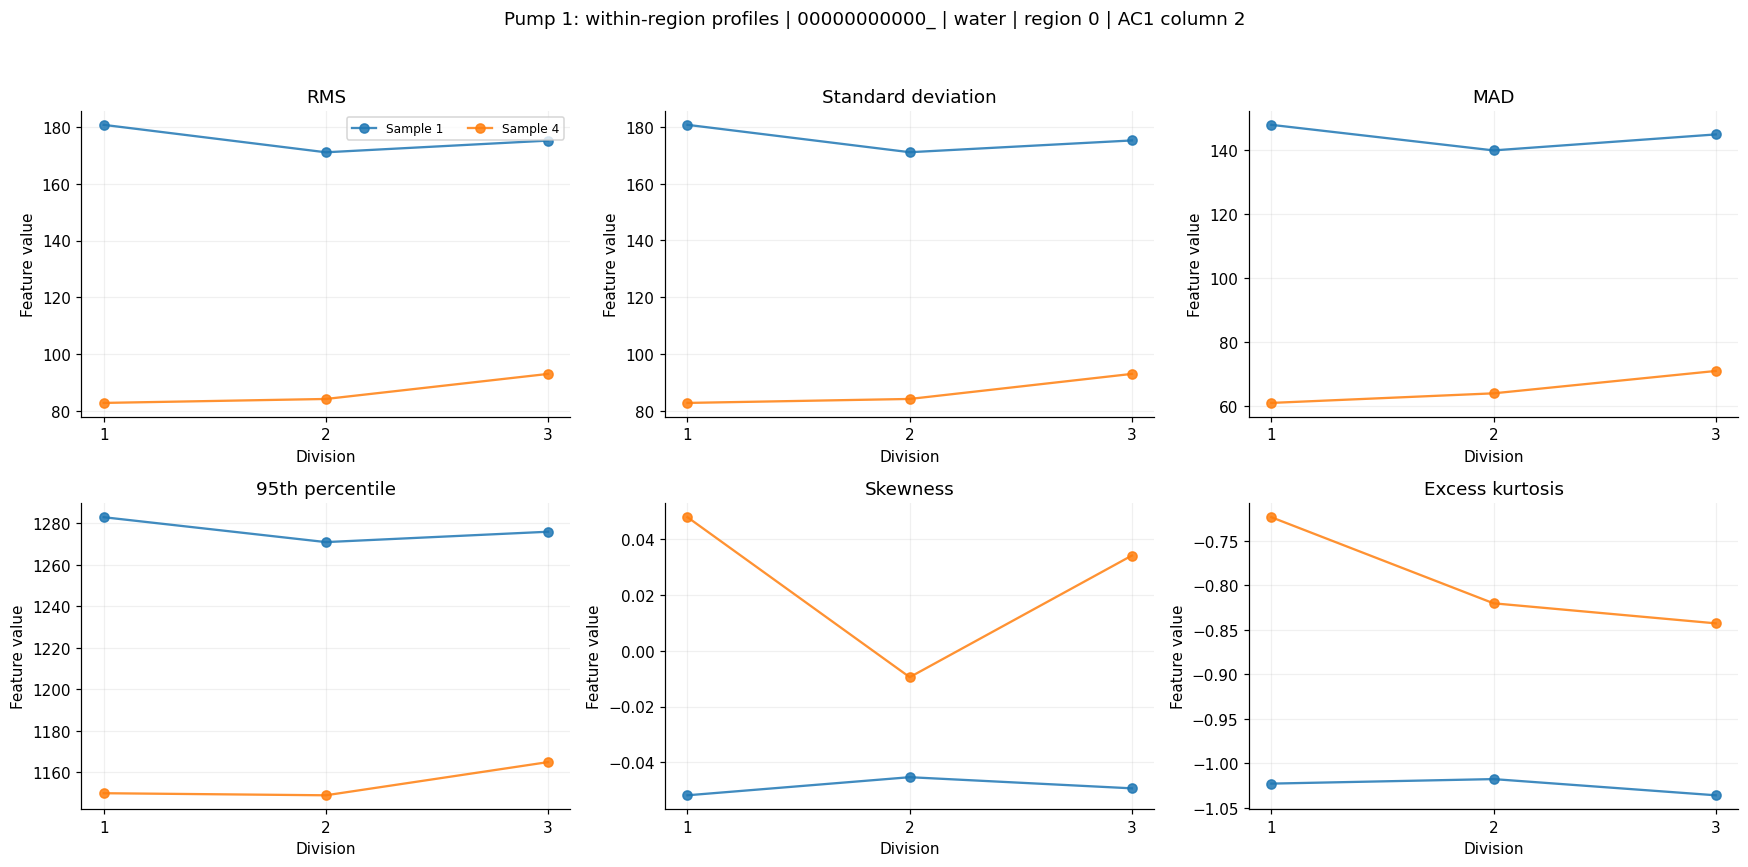

In [98]:
def plot_within_pump(pump_id):
    pump_id = normalize_id(pump_id)
    data = feature_table[feature_table.pump_id==pump_id]
    if data.empty:
        raise ValueError(f"No features for pump {pump_id}")
    samples = sorted(data.sample_id.unique(),key=int)
    fig, axes = plt.subplots(2,3,figsize=(16,8),squeeze=False)
    for ax, feature in zip(axes.flat,FEATURES):
        for sample in samples:
            values=data[data.sample_id==sample].sort_values("division")
            ax.plot(values.division,values[feature],marker="o",label=f"Sample {sample}",alpha=0.85)
        ax.set(title=LABELS[feature],xlabel="Division",xticks=range(1,N_DIVISIONS+1),ylabel="Feature value")
    axes[0,0].legend(fontsize=8,ncol=2)
    fig.suptitle(f"Pump {pump_id}: within-region profiles | {selection_title}")
    finish_plot(fig,f"within_pump_{pump_id}_division_profiles")

plot_within_pump(focus_pump)

## 7. Within one pump: compare samples at a fixed division

One line per division; x-axis = sample ID (categorical, not elapsed time). Compare values along the same coloured line to judge sample-to-sample repeatability at that region position.

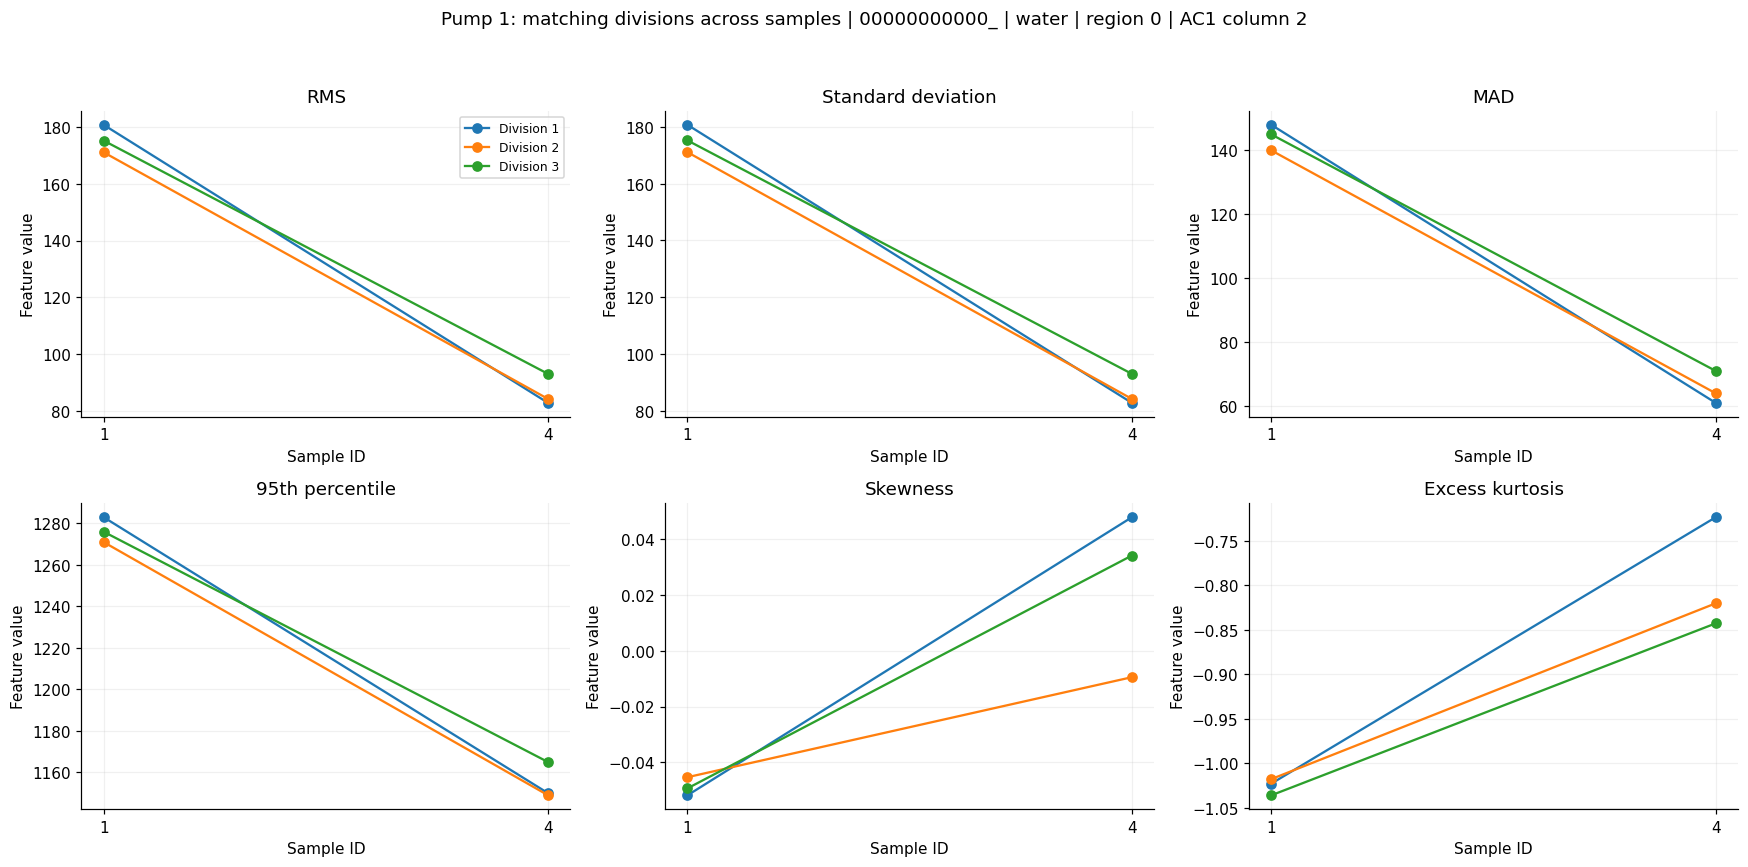

In [99]:
def plot_samples_at_divisions(pump_id):
    pump_id=normalize_id(pump_id)
    data=feature_table[feature_table.pump_id==pump_id]
    if data.empty:
        raise ValueError(f"No features for pump {pump_id}")
    samples=sorted(data.sample_id.unique(),key=int)
    fig,axes=plt.subplots(2,3,figsize=(16,8))
    for ax,feature in zip(axes.flat,FEATURES):
        for division in range(1,N_DIVISIONS+1):
            values=data[data.division==division].set_index("sample_id").reindex(samples)
            ax.plot(range(len(samples)),values[feature],marker="o",label=f"Division {division}")
        ax.set(title=LABELS[feature],xlabel="Sample ID",ylabel="Feature value",
               xticks=range(len(samples)),xticklabels=samples)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f"Pump {pump_id}: matching divisions across samples | {selection_title}")
    finish_plot(fig,f"within_pump_{pump_id}_samples")

plot_samples_at_divisions(focus_pump)

## 8. Between pumps: compare the same region and division

Small dots are individual samples; large markers are per-pump means, with ±1 sample SD error bars. Colours identify matching divisions. Means give each sample equal weight regardless of the region's duration. A single sample has no estimable SD, so its error bar is omitted. Different pump means can reflect physical variability, calibration, acquisition settings or alignment—not necessarily a different fault.

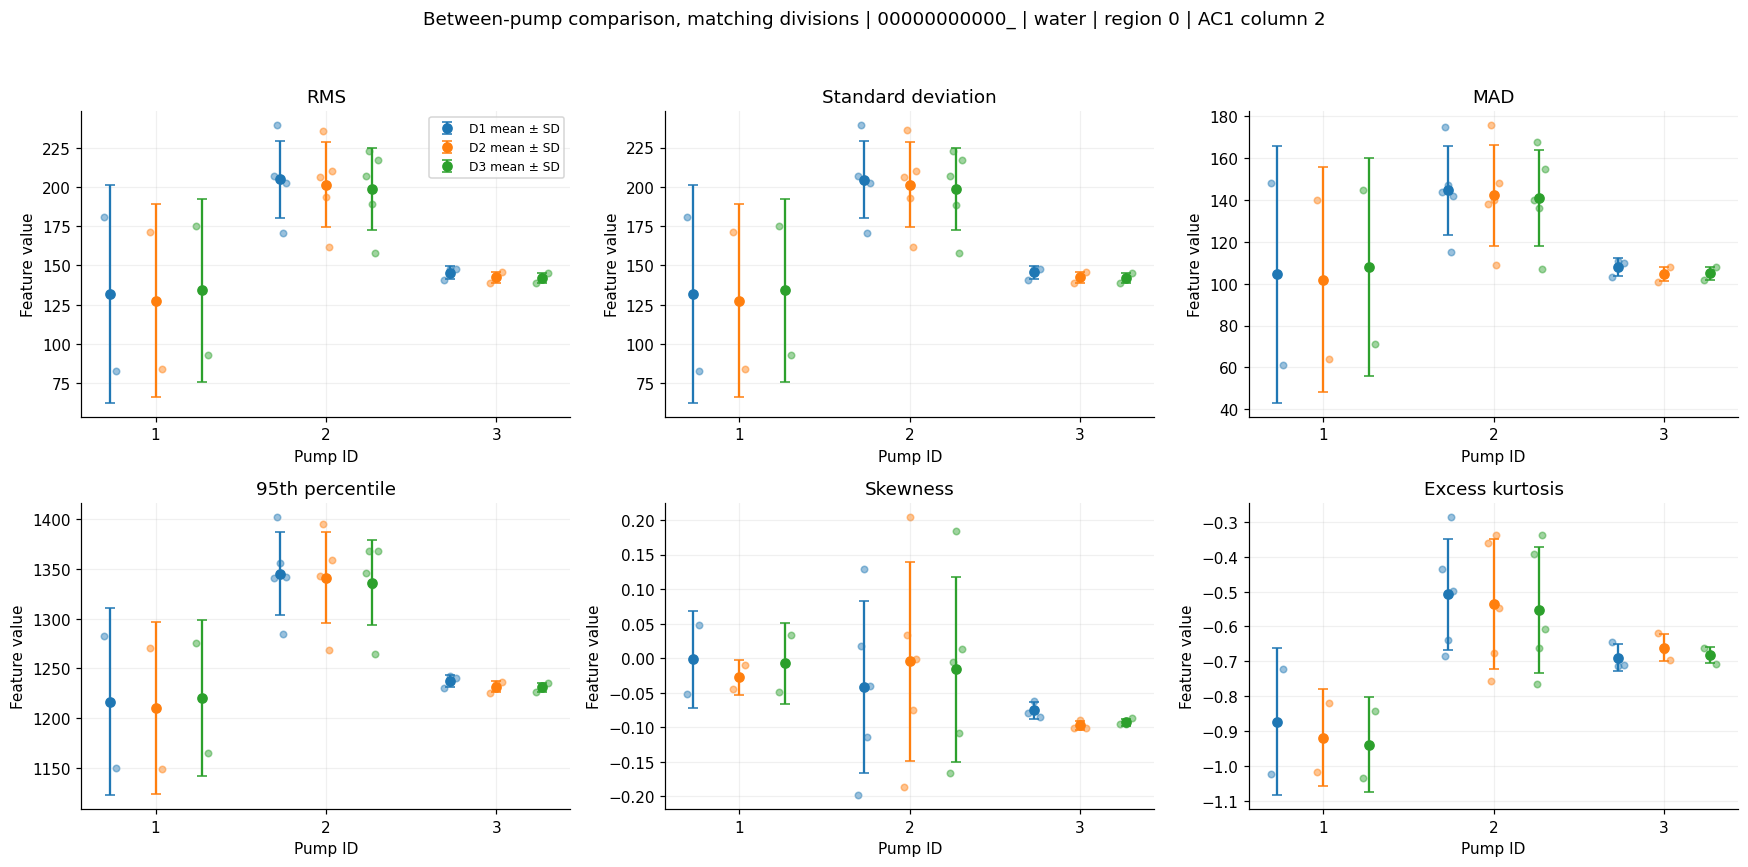

,pump_id,division,feature,n,mean,sd,minimum,maximum,range,cv_pct
0,1,1,kurt,2,-0.87304,0.21167,-1.02272,-0.72336,0.29935,NaN
1,1,1,mad,2,104.50000,61.51829,61.00000,148.00000,87.00000,58.86918
2,1,1,q95,2,1216.50000,94.04520,1150.00000,1283.00000,133.00000,NaN
3,1,1,rms,2,131.77989,69.32449,82.76008,180.79971,98.03963,52.60627
4,1,1,skew,2,-0.00194,0.07061,-0.05187,0.04799,0.09986,NaN
5,1,1,std,2,131.74225,69.28127,82.75299,180.73151,97.97852,52.58850
6,1,2,kurt,2,-0.91887,0.13967,-1.01764,-0.82011,0.19753,NaN
7,1,2,mad,2,102.00000,53.74012,64.00000,140.00000,76.00000,52.68639
8,1,2,q95,2,1210.00000,86.26703,1149.00000,1271.00000,122.00000,NaN
9,1,2,rms,2,127.63583,61.49462,84.15257,171.11908,86.96652,48.17975


In [100]:
long_features = feature_table.melt(
    id_vars=["fault_id","state","region","pump_id","sample_id","division"],
    value_vars=FEATURES,var_name="feature",value_name="value")
pump_summary = long_features.groupby(["pump_id","division","feature"]).value.agg(
    n="count",mean="mean",sd="std",minimum="min",maximum="max").reset_index()
pump_summary["range"] = pump_summary.maximum-pump_summary.minimum
# Relative SD is intentionally restricted to nonnegative scale features.
# It is not interpretable for near-zero signed skewness/kurtosis.
pump_summary["cv_pct"] = np.nan
mask=pump_summary.feature.isin(["rms","std","mad"]) & (pump_summary["mean"].abs()>1e-12)
pump_summary.loc[mask,"cv_pct"] = 100*pump_summary.loc[mask,"sd"]/pump_summary.loc[mask,"mean"].abs()

def plot_between_pumps():
    pumps=sorted(feature_table.pump_id.unique(),key=int)
    offsets=np.linspace(-0.27,0.27,N_DIVISIONS) if N_DIVISIONS>1 else [0.0]
    fig,axes=plt.subplots(2,3,figsize=(16,8))
    for ax,feature in zip(axes.flat,FEATURES):
        for division,offset in enumerate(offsets,start=1):
            color=plt.cm.tab10((division-1)%10)
            for pos,pump in enumerate(pumps):
                values=feature_table[(feature_table.pump_id==pump)&(feature_table.division==division)][feature]
                jitter=np.linspace(-0.035,0.035,len(values)) if len(values)>1 else np.array([0.0])
                ax.scatter(pos+offset+jitter,values,color=color,s=18,alpha=0.45)
                mean=float(values.mean()); sd=float(values.std(ddof=1))
                ax.errorbar(pos+offset,mean,yerr=sd if np.isfinite(sd) else None,
                            fmt="o",color=color,markersize=6,capsize=3,
                            label=f"D{division} mean ± SD" if pos==0 else None)
        ax.set(title=LABELS[feature],xlabel="Pump ID",ylabel="Feature value",
               xticks=range(len(pumps)),xticklabels=pumps)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f"Between-pump comparison, matching divisions | {selection_title}")
    finish_plot(fig,"between_pumps")

plot_between_pumps()
display(pump_summary.round(5))

## 9. Feature heatmaps: every sample × division

Each heatmap uses its own feature's raw numerical scale. Rows are labelled pump/sample and separated by pump; columns are divisions of the selected region. Similar colours within one column indicate similar values at the same region position. Colours are not comparable between different feature panels.

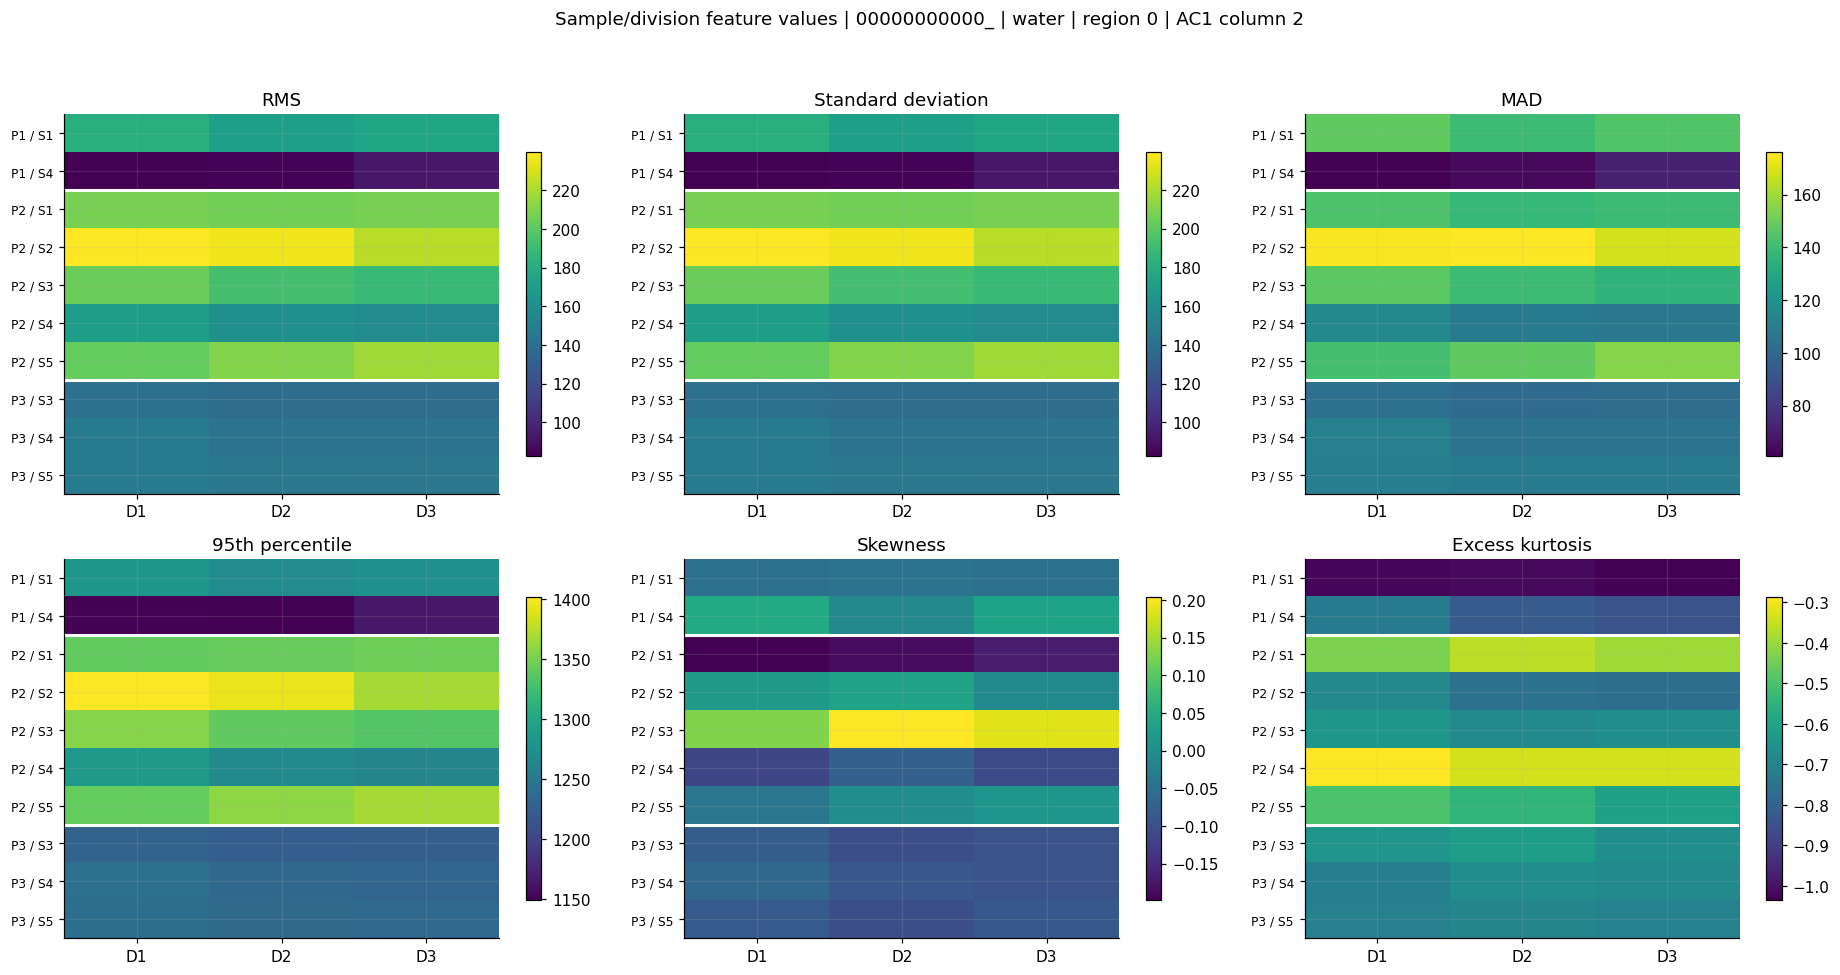

In [101]:
def plot_feature_heatmaps():
    row_order=list(selected[["pump_id","sample_id"]].itertuples(index=False,name=None))
    fig,axes=plt.subplots(2,3,figsize=(17,max(9,0.36*len(row_order))))
    for ax,feature in zip(axes.flat,FEATURES):
        matrix=feature_table.pivot(index=["pump_id","sample_id"],columns="division",values=feature)
        matrix=matrix.reindex(index=pd.MultiIndex.from_tuples(row_order,names=["pump_id","sample_id"]),
                              columns=range(1,N_DIVISIONS+1))
        image=ax.imshow(matrix.to_numpy(),aspect="auto",cmap="viridis")
        ax.set(title=LABELS[feature],xticks=range(N_DIVISIONS),
               xticklabels=[f"D{i}" for i in range(1,N_DIVISIONS+1)],
               yticks=range(len(row_order)),yticklabels=[f"P{p} / S{s}" for p,s in row_order])
        ax.tick_params(axis="y",labelsize=8)
        for i in range(1,len(row_order)):
            if row_order[i][0]!=row_order[i-1][0]:
                ax.axhline(i-0.5,color="white",lw=2)
        fig.colorbar(image,ax=ax,shrink=0.8)
    fig.suptitle(f"Sample/division feature values | {selection_title}")
    finish_plot(fig,"feature_heatmaps")

plot_feature_heatmaps()

## 10. Quantify three different sources of variation

- **Within a sample, across divisions:** highlights transitions or drift. This is descriptive variation over a trajectory, not repeated-measure noise.
- **Within a pump, across samples at the same division:** sample-to-sample repeatability (`pump_summary` above).
- **Between pump means at the same division:** physical-pump differences. `pooled_within_pump_sd` pools sample variances using sample degrees of freedom; `between_pump_sd` is the SD of pump means with equal weight per pump. Their ratio is descriptive, not a significance test or pure variance-component estimate. Undefined ratios remain NaN.

There is no automatic pass/fail threshold: practical tolerances must reflect the sensor's units and expected operating variation. Higher variation between pumps than within a pump can explain why unknown-pump classification is harder.

,pump_id,sample_id,feature,divisions,mean,sd_across_divisions,minimum,maximum,range_across_divisions
0,1,1,kurt,3,-1.02540,0.00939,-1.03584,-1.01764,0.01820
1,1,1,mad,3,144.33333,4.04145,140.00000,148.00000,8.00000
2,1,1,q95,3,1276.66667,6.02771,1271.00000,1283.00000,12.00000
3,1,1,rms,3,175.72002,4.85804,171.11908,180.79971,9.68062
4,1,1,skew,3,-0.04888,0.00328,-0.05187,-0.04538,0.00650
5,1,1,std,3,175.68324,4.83896,171.08504,180.73151,9.64647
6,1,4,kurt,3,-0.79537,0.06337,-0.84263,-0.72336,0.11927
7,1,4,mad,3,65.33333,5.13160,61.00000,71.00000,10.00000
8,1,4,q95,3,1154.66667,8.96289,1149.00000,1165.00000,16.00000
9,1,4,rms,3,86.63342,5.54677,82.76008,92.98763,10.22755


,division,feature,pumps,pump_mean_min,pump_mean_max,pooled_within_pump_sd,between_pump_sd,between_to_within_sd_ratio,between_pump_cv_pct
0,1,kurt,3,-0.87304,-0.50816,0.14660,0.18244,1.24450,NaN
1,1,mad,3,104.50000,144.60000,28.37428,22.21043,0.78277,18.65900
2,1,q95,3,1216.50000,1345.20000,47.69242,69.08079,1.44846,NaN
3,1,rms,3,131.77989,204.77436,32.14438,38.79070,1.20676,24.14000
4,1,skew,3,-0.07575,-0.00194,0.09839,0.03694,0.37539,NaN
5,1,std,3,131.74225,204.64580,32.11421,38.73731,1.20624,24.11654
6,2,kurt,3,-0.91887,-0.53531,0.15187,0.19558,1.28783,NaN
7,2,mad,3,102.00000,142.20000,27.29068,22.47926,0.82370,19.33053
8,2,q95,3,1210.00000,1341.20000,47.71862,70.33306,1.47391,NaN
9,2,rms,3,127.63583,201.48649,31.06368,39.06126,1.25746,24.84721


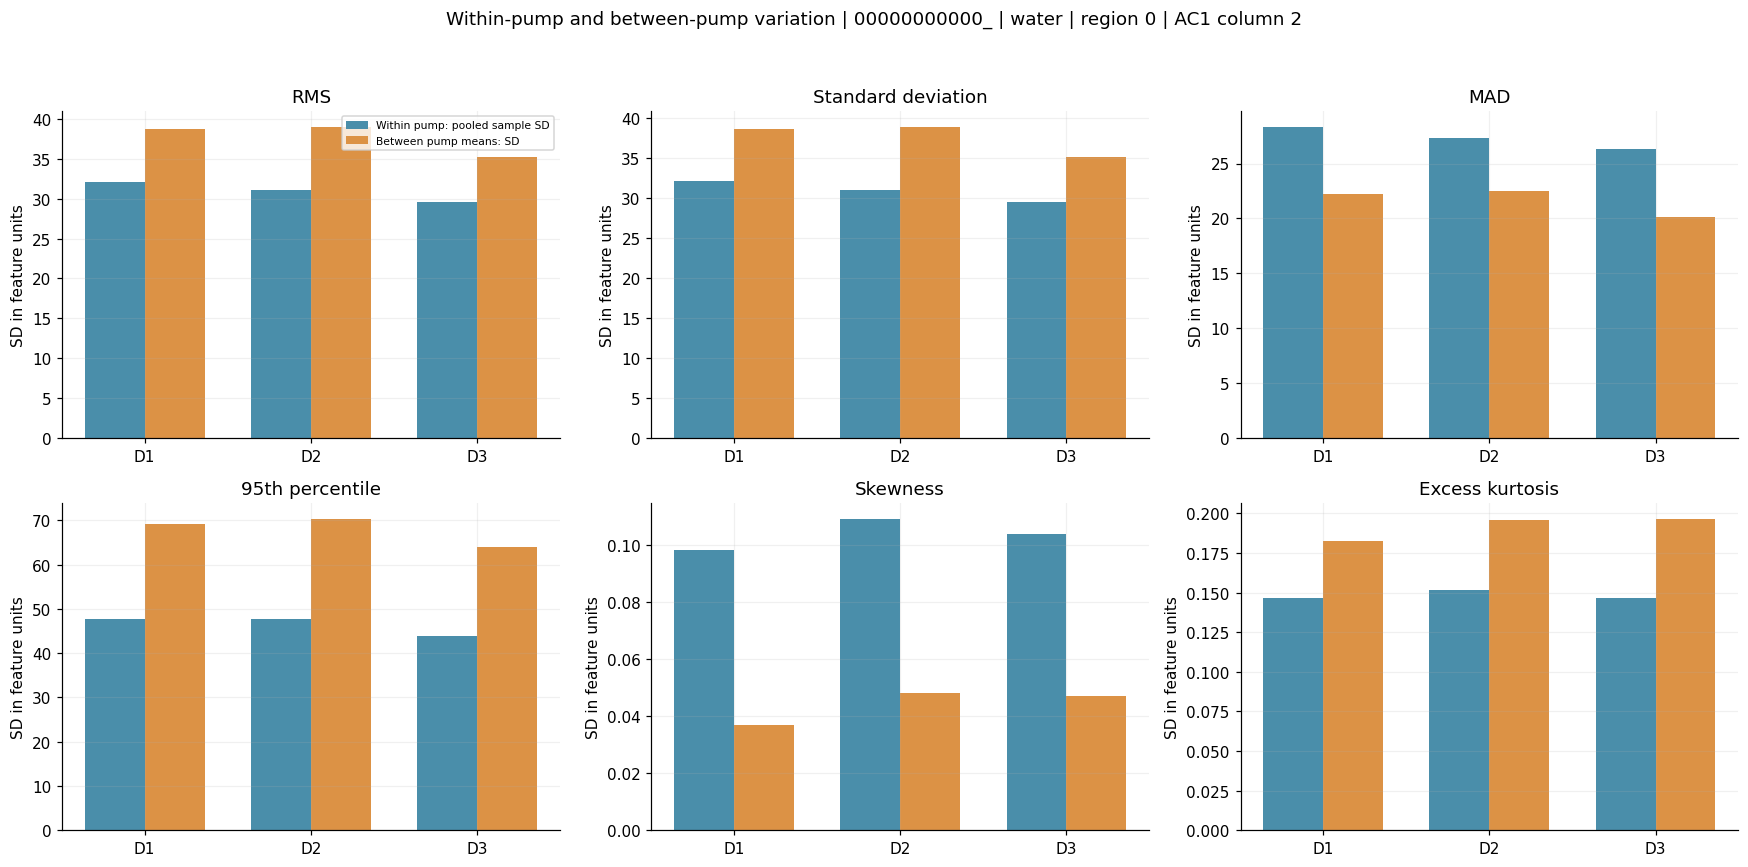

In [102]:
within_sample = long_features.groupby(["pump_id","sample_id","feature"]).value.agg(
    divisions="count",mean="mean",sd_across_divisions="std",minimum="min",maximum="max").reset_index()
within_sample["range_across_divisions"] = within_sample.maximum-within_sample.minimum

variation_rows=[]
for (division,feature), group in pump_summary.groupby(["division","feature"]):
    dof=(group.n-1).clip(lower=0)
    denominator=float(dof.sum())
    pooled=np.sqrt(float(((dof*group.sd**2).fillna(0)).sum())/denominator) if denominator>0 else np.nan
    between=float(group["mean"].std(ddof=1))
    grand=float(group["mean"].mean())
    variation_rows.append({"division":division,"feature":feature,"pumps":len(group),
        "pump_mean_min":float(group["mean"].min()),"pump_mean_max":float(group["mean"].max()),
        "pooled_within_pump_sd":pooled,"between_pump_sd":between,
        "between_to_within_sd_ratio":between/pooled if np.isfinite(pooled) and pooled>1e-12 else np.nan,
        "between_pump_cv_pct":100*between/abs(grand)
            if feature in ["rms","std","mad"] and abs(grand)>1e-12 else np.nan})
variation_summary=pd.DataFrame(variation_rows)
display(within_sample.round(5))
display(variation_summary.round(5))

fig,axes=plt.subplots(2,3,figsize=(16,8))
for ax,feature in zip(axes.flat,FEATURES):
    data=variation_summary[variation_summary.feature==feature].sort_values("division")
    x=np.arange(len(data))
    ax.bar(x-0.18,data.pooled_within_pump_sd,width=0.36,label="Within pump: pooled sample SD",color="#4a8eaa")
    ax.bar(x+0.18,data.between_pump_sd,width=0.36,label="Between pump means: SD",color="#dc9245")
    ax.set(title=LABELS[feature],xticks=x,xticklabels=[f"D{i}" for i in data.division],ylabel="SD in feature units")
axes[0,0].legend(fontsize=7)
fig.suptitle(f"Within-pump and between-pump variation | {selection_title}")
finish_plot(fig,"variation_summary")

## 11. Optional exports and changing the selection

Set `EXPORT_TABLES=True` to write the diagnostic tables and settings here. Set `SAVE_PLOTS=True` before running plotting cells to save their PNGs. Outputs go to a separate comparison directory; rerunning the same selection replaces only its diagnostic outputs. No training feature files are overwritten.

For another fault/state/region, edit the selection cell and rerun from the inventory cell. For another already-loaded pump, run `plot_within_pump(2)`, `plot_samples_at_divisions(2)` or `plot_signal_regions(2)`. For another signal/channel, change `SIGNAL` / `COLUMN` and reload.

In [103]:
if EXPORT_TABLES:
    import json
    output_dir.mkdir(parents=True,exist_ok=True)
    for name,table in [("division_features",feature_table),("within_pump_sample_variation",pump_summary),
                       ("within_sample_division_variation",within_sample),("between_pump_variation",variation_summary)]:
        table.to_csv(output_dir/f"{name}.csv",index=False)
    settings={"fault_id":FAULT_ID,"state":STATE,"region":REGION,"signal":SIGNAL,"column":COLUMN,
              "divisions":N_DIVISIONS,"edge_seconds":REGION_EDGE_SECONDS,"trim_quantiles":TRIM_QUANTILES,
              "features":FEATURES,"sample_keys":selected.sample_id_key.tolist(),
              "metadata_path":str(META_PATH),"timestamps_path":str(TIMESTAMPS_PATH)}
    (output_dir/"comparison_settings.json").write_text(json.dumps(settings,indent=2))
    print("Saved diagnostic tables:",output_dir.resolve())
else:
    print("Display-only mode: no diagnostic tables written.")

Display-only mode: no diagnostic tables written.
